# NFL Game Outcome Prediction (2018–2023)

In this notebook I try to predict whether the **home team wins** an NFL game using
publicly available pre game information.

The main questions I look at are:

1. How strong are simple baselines like:
   - always picking the **home team**
   - always picking the **betting favorite**?
2. Can I build a **non-market model** that uses only team performance and basic information about the game?
3. If I combine **team form** with **Vegas betting lines**, can I get a model that:
   - slightly beats the betting favorite in accuracy, and  
   - gives better probability estimates (measured by ROC AUC)?

For this project, I used regular-season NFL games from 2018–2023 and logistic regression models.

## Exploratory Data Analysis

### Imports and Data Loading

In [1]:
import nfl_data_py as nfl 
# The `nfl-data-py` package was installed locally prior to running this notebook

import numpy as np
import pandas as pd
import nfl_data_py as nfl

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)

sns.set(style="whitegrid")

In [2]:
seasons = list(range(2018, 2024))

In [3]:
games = nfl.import_schedules(seasons)
games = games[games["game_type"] == "REG"].copy()
games

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
5049,2018_01_ATL_PHI,2018,REG,1,2018-09-06,Thursday,20:20,ATL,12.0,PHI,...,8.0,00-0026143,00-0029567,Matt Ryan,Nick Foles,Dan Quinn,Doug Pederson,John Hussey,PHI00,Lincoln Financial Field
5050,2018_01_BUF_BAL,2018,REG,1,2018-09-09,Sunday,13:00,BUF,3.0,BAL,...,12.0,00-0033958,00-0026158,Nathan Peterman,Joe Flacco,Sean McDermott,John Harbaugh,Shawn Hochuli,BAL00,M&T Bank Stadium
5051,2018_01_PIT_CLE,2018,REG,1,2018-09-09,Sunday,13:00,PIT,21.0,CLE,...,11.0,00-0022924,00-0028118,Ben Roethlisberger,Tyrod Taylor,Mike Tomlin,Hue Jackson,Shawn Smith,CLE00,FirstEnergy Stadium
5052,2018_01_CIN_IND,2018,REG,1,2018-09-09,Sunday,13:00,CIN,34.0,IND,...,NaN,00-0027973,00-0029668,Andy Dalton,Andrew Luck,Marvin Lewis,Frank Reich,Peter Morelli,IND00,Lucas Oil Stadium
5053,2018_01_TEN_MIA,2018,REG,1,2018-09-09,Sunday,13:00,TEN,20.0,MIA,...,7.0,00-0032268,00-0029701,Marcus Mariota,Ryan Tannehill,Mike Vrabel,Adam Gase,Jerome Boger,MIA00,Hard Rock Stadium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6688,2023_18_DEN_LV,2023,REG,18,2024-01-07,Sunday,16:25,DEN,14.0,LV,...,NaN,00-0035264,00-0038579,Jarrett Stidham,Aidan O'Connell,Sean Payton,Antonio Pierce,Shawn Hochuli,VEG00,Allegiant Stadium
6689,2023_18_PHI_NYG,2023,REG,18,2024-01-07,Sunday,16:25,PHI,10.0,NYG,...,12.0,00-0036389,00-0028118,Jalen Hurts,Tyrod Taylor,Nick Sirianni,Brian Daboll,Craig Wrolstad,NYC01,MetLife Stadium
6690,2023_18_LA_SF,2023,REG,18,2024-01-07,Sunday,16:25,LA,21.0,SF,...,11.0,00-0032950,00-0034869,Carson Wentz,Sam Darnold,Sean McVay,Kyle Shanahan,Clay Martin,SFO01,Levi's Stadium
6691,2023_18_DAL_WAS,2023,REG,18,2024-01-07,Sunday,16:25,DAL,38.0,WAS,...,13.0,00-0033077,00-0037077,Dak Prescott,Sam Howell,Mike McCarthy,Ron Rivera,Shawn Smith,WAS00,FedExField


### Dataset Overview

In [4]:
games.shape

(1583, 46)

In [5]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1583 entries, 5049 to 6692
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           1583 non-null   object 
 1   season            1583 non-null   int64  
 2   game_type         1583 non-null   object 
 3   week              1583 non-null   int64  
 4   gameday           1583 non-null   object 
 5   weekday           1583 non-null   object 
 6   gametime          1583 non-null   object 
 7   away_team         1583 non-null   object 
 8   away_score        1583 non-null   float64
 9   home_team         1583 non-null   object 
 10  home_score        1583 non-null   float64
 11  location          1583 non-null   object 
 12  result            1583 non-null   float64
 13  total             1583 non-null   float64
 14  overtime          1583 non-null   float64
 15  old_game_id       1583 non-null   int64  
 16  gsis              1583 non-null   float

### Our "Useful Columns"
These are the "basic" features used later in the models. All of these values are known before the game starts and describe the basic game conditions.

- **`home_rest`** – The number of days since the home team last played.

- **`away_rest`** – The number of days since the away team last played.

- **`div_game`** – Indicates whether the two teams are in the same division  
  (1 = divisional game, 0 = non-divisional).

- **`temp`** – The temperature at the time of the game (Fahrenheit).

- **`wind`** – The wind speed during the game (mph).

In [6]:
useful_cols = [ "home_rest", "away_rest", "div_game", "temp", "wind"]
games[useful_cols].isna().sum()

home_rest      0
away_rest      0
div_game       0
temp         609
wind         609
dtype: int64

### Addressing Empty Temp + Wind Values
For my model, I determined that playing in a dome would negate any sort of wind and would generally have a fixed temperature of 70 degrees in order to regulate these values. Additionally, the median value was used to impute any other NaNs in order to account for any outliers

In [7]:
games["temp_imputed"] = games["temp"]
games["wind_imputed"] = games["wind"]

# Dome / indoor handling
dome_mask = games["roof"].str.lower().str.contains("dome|closed|indoor")
games.loc[dome_mask, "temp_imputed"] = 70
games.loc[dome_mask, "wind_imputed"] = 0

# Median imputation for remaining NaNs
games["temp_imputed"] = games["temp_imputed"].fillna(games["temp_imputed"].median())
games["wind_imputed"] = games["wind_imputed"].fillna(games["wind_imputed"].median())
games[['temp_imputed', 'wind_imputed']].head(5)

,temp_imputed,wind_imputed
5049,81.0,8.0
5050,61.0,12.0
5051,58.0,11.0
5052,70.0,0.0
5053,89.0,7.0


### Determining the Target Variable: Home Team Win
We determine that the target is whether the home team wins or not. They will be given a:
- 1  If the home team wins
- 0  If the home team loses or in the rare case of a tie

In [8]:
games["home_win"] = (games["home_score"] > games["away_score"]).astype(int)
home_win_rate = games["home_win"].mean()
print("Overall home win rate:", round(home_win_rate, 3))

Overall home win rate: 0.539


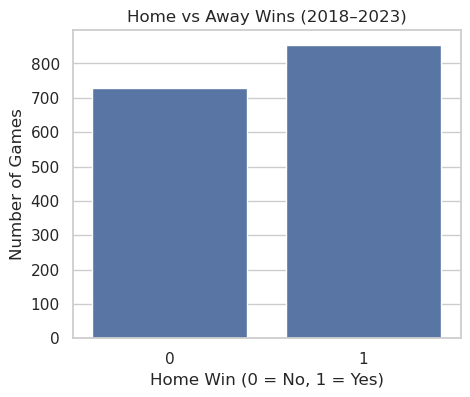

In [9]:
plt.figure(figsize=(5, 4))
sns.countplot(x="home_win", data=games)
plt.title("Home vs Away Wins (2018–2023)")
plt.xlabel("Home Win (0 = No, 1 = Yes)")
plt.ylabel("Number of Games")
plt.show()

### Point Differential Analysis

In [10]:
games["point_diff"] = games["home_score"] - games["away_score"]
print("Median point differential:", games["point_diff"].median())

Median point differential: 2.0


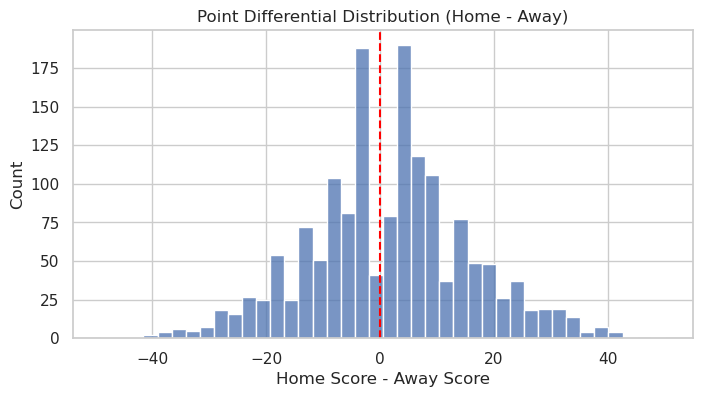

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(games["point_diff"], bins=40)
plt.axvline(0, color="red", linestyle="--")
plt.title("Point Differential Distribution (Home - Away)")
plt.xlabel("Home Score - Away Score")
plt.show()

### Home Win Rate by Season

In [12]:
wins_by_season = games.groupby("season")["home_win"].mean()
wins_by_season

season
2018    0.597656
2019    0.515625
2020    0.496094
2021    0.514706
2022    0.557196
2023    0.555147
Name: home_win, dtype: float64

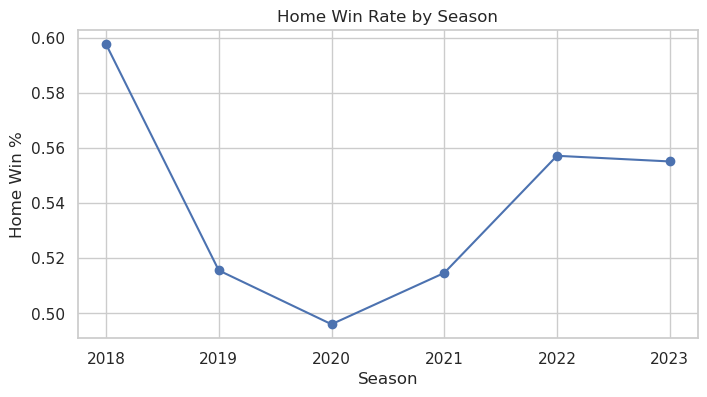

In [13]:
plt.figure(figsize=(8,4))
wins_by_season.plot(marker="o")
plt.title("Home Win Rate by Season")
plt.ylabel("Home Win %")
plt.xlabel("Season")
plt.grid(True)
plt.show()

### Looking at the betting "Favorites"
We compare the betting odds of both teams per each game, and determine the team that has to lower moneyline to be the 'favorite' to win the game. And on the other hand, the team with the higher moneyline will be classified as the underdog

In [14]:
games["favorite"] = np.where(
    games["home_moneyline"] < games["away_moneyline"],
    "home",
    "away"
)

games["favorite_won"] = np.where(
    (games["favorite"] == "home") & (games["home_win"] == 1), 1,
    np.where((games["favorite"] == "away") & (games["home_win"] == 0), 1, 0)
)

favorite_win_rate = games["favorite_won"].mean()

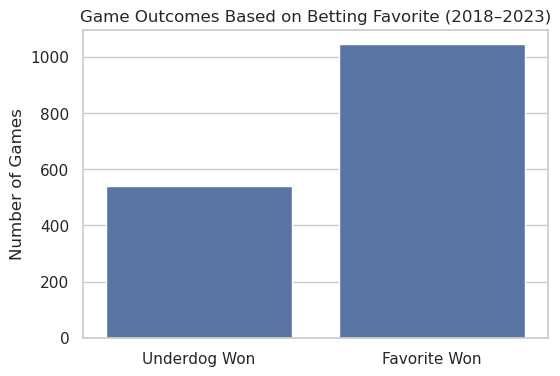

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="favorite_won", data=games)
plt.xticks([0, 1], ["Underdog Won", "Favorite Won"])
plt.title("Game Outcomes Based on Betting Favorite (2018–2023)")
plt.ylabel("Number of Games")
plt.xlabel("")
plt.show()

In [16]:
print("Betting favorite win rate:", round(favorite_win_rate, 3))

Betting favorite win rate: 0.66


## Modeling

### Train/Test Split

In [17]:
games_model = games.copy()

# Train on games from 2018–2022, and test on 2023 season
train_mask = games_model["season"] <= 2022
test_mask  = games_model["season"] >= 2023

y_train = games_model.loc[train_mask, "home_win"]
y_test  = games_model.loc[test_mask, "home_win"]

y_train.shape, y_test.shape

((1311,), (272,))

### Baseline Models

We first define two simple baselines:

1. **Home Team Baseline**: always predicts that the home team wins.
2. **Betting Favorite Baseline**: predicts that the team with the lower moneyline wins. The "Vegas Line"

In [18]:
home_baseline_preds = np.ones_like(y_test)
home_baseline_acc = (home_baseline_preds == y_test.values).mean()

favorite_home = (games_model["home_moneyline"] < games_model["away_moneyline"]).astype(int)

fav_baseline_acc = (
    favorite_home.loc[test_mask].values == y_test.values
).mean()

home_baseline_acc, fav_baseline_acc

(0.5551470588235294, 0.6838235294117647)

On the 2024 test set:
- Always picking the **home team** gives about **55.5% accuracy**.
- Always picking the **betting favorite** gives about **68.4% accuracy**.

The favorite baseline is already very competitive, so anything we build needs to be compared against this.

#### Logistic Regression Setup

To keep things organized, I use the same logistic regression setup for all models:
- standardize the features
- fit a logistic regression
- report accuracy, log loss, and ROC AUC

In [19]:
def run_logistic_model(feature_cols, name):
    """
    Fit a logistic regression model on the given feature columns,
    print metrics, and return (probs, preds, metrics_dict).
    """
    X_train = games_model.loc[train_mask, feature_cols]
    X_test = games_model.loc[test_mask, feature_cols]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=3000)
    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(X_test_scaled)[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    ll = log_loss(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    print(f"{name}")
    print("  Accuracy:", round(acc, 3))
    print("  Log loss:", round(ll, 3))
    print("  ROC AUC:", round(auc, 3))
    print()

    metrics = {
        "Model": name,
        "Accuracy": acc,
        "Log Loss": ll,
        "ROC AUC": auc,
    }
    return probs, preds, metrics

### Model 1 - Basic Non-Market Logistic Regression

In [20]:
features_basic_non_market = [
    "home_rest",
    "away_rest",
    "div_game",
    "temp_imputed",
    "wind_imputed",
]

basic_non_market_probs, basic_non_market_preds, basic_non_market_metrics = run_logistic_model(
    features_basic_non_market,
    "Logistic (No Market: Basic)",
)

Logistic (No Market: Basic)
  Accuracy: 0.544
  Log loss: 0.688
  ROC AUC: 0.507



#### Create Features For Recent Team Form
These features try to capture how "hot" or "cold" each team is coming into the game. This code takes into consideration the recent point differentials and overall performance from the past 5 games as a numerical value.

In [21]:
games_model = games_model.sort_values(["season", "week", "game_id"]).reset_index(drop=True)

rows = []
for _, g in games_model.iterrows():
    # Home team row
    rows.append({
        "game_id": g["game_id"],
        "season": g["season"],
        "week": g["week"],
        "team": g["home_team"],
        "is_home": 1,
        "points_for": g["home_score"],
        "points_against": g["away_score"],
    })
    # Away team row
    rows.append({
        "game_id": g["game_id"],
        "season": g["season"],
        "week": g["week"],
        "team": g["away_team"],
        "is_home": 0,
        "points_for": g["away_score"],
        "points_against": g["home_score"],
    })

team_games = pd.DataFrame(rows)

team_games["win"] = (team_games["points_for"] > team_games["points_against"]).astype(int)
team_games["point_diff"] = team_games["points_for"] - team_games["points_against"]
team_games["game_no"] = team_games.groupby("team").cumcount()

# Rolling features based only on past 5 games
g_team = team_games.groupby("team", group_keys=False)

team_games["win_pct_last5"] = g_team["win"].apply(
    lambda x: x.shift().rolling(5, min_periods=1).mean()
)
team_games["avg_pd_last5"] = g_team["point_diff"].apply(
    lambda x: x.shift().rolling(5, min_periods=1).mean()
)
team_games["points_for_last5"] = g_team["points_for"].apply(
    lambda x: x.shift().rolling(5, min_periods=1).mean()
)
team_games["points_against_last5"] = g_team["points_against"].apply(
    lambda x: x.shift().rolling(5, min_periods=1).mean()
)

team_games["cum_win_pct"] = g_team["win"].apply(
    lambda x: x.shift().expanding().mean()
)
team_games["cum_avg_pd"] = g_team["point_diff"].apply(
    lambda x: x.shift().expanding().mean()
)

# Fill the first 4 games of each season with column means
for col in [
    "win_pct_last5",
    "avg_pd_last5",
    "points_for_last5",
    "points_against_last5",
    "cum_win_pct",
    "cum_avg_pd",
]:
    team_games[col] = team_games[col].fillna(team_games[col].mean())

In [22]:
# Merge team-level features back into games_model

home_feats = (
    team_games[team_games["is_home"] == 1][
        [
            "game_id",
            "win_pct_last5",
            "avg_pd_last5",
            "points_for_last5",
            "points_against_last5",
            "cum_win_pct",
            "cum_avg_pd",
        ]
    ]
    .add_prefix("home_")
)

away_feats = (
    team_games[team_games["is_home"] == 0][
        [
            "game_id",
            "win_pct_last5",
            "avg_pd_last5",
            "points_for_last5",
            "points_against_last5",
            "cum_win_pct",
            "cum_avg_pd",
        ]
    ]
    .add_prefix("away_")
)

games_model = games_model.merge(
    home_feats, left_on="game_id", right_on="home_game_id", how="left"
)
games_model = games_model.merge(
    away_feats, left_on="game_id", right_on="away_game_id", how="left"
)

games_model = games_model.drop(columns=["home_game_id", "away_game_id"])

# Difference features: home - away
games_model["win_pct_last5_diff"] = (
    games_model["home_win_pct_last5"] - games_model["away_win_pct_last5"]
)
games_model["avg_pd_last5_diff"] = (
    games_model["home_avg_pd_last5"] - games_model["away_avg_pd_last5"]
)
games_model["points_for_last5_diff"] = (
    games_model["home_points_for_last5"] - games_model["away_points_for_last5"]
)
games_model["points_against_last5_diff"] = (
    games_model["home_points_against_last5"] - games_model["away_points_against_last5"]
)
games_model["cum_win_pct_diff"] = (
    games_model["home_cum_win_pct"] - games_model["away_cum_win_pct"]
)
games_model["cum_avg_pd_diff"] = (
    games_model["home_cum_avg_pd"] - games_model["away_cum_avg_pd"]
)

games_model[
    ["win_pct_last5_diff", "avg_pd_last5_diff", "cum_win_pct_diff", "cum_avg_pd_diff"]
].describe()


,win_pct_last5_diff,avg_pd_last5_diff,cum_win_pct_diff,cum_avg_pd_diff
count,1583.000000,1583.000000,1583.000000,1583.000000
mean,-0.007621,-0.311470,-0.001429,-0.019348
std,0.365529,11.177538,0.227251,7.467222
min,-1.000000,-41.200000,-1.000000,-34.000000
25%,-0.200000,-7.600000,-0.153846,-4.915026
50%,0.000000,0.000000,0.000000,0.000000
75%,0.200000,6.600000,0.149148,4.876389
max,1.000000,38.000000,1.000000,38.000000


### Model 2 - Enhanced Non-Market Model (Basic + Team Form)

In [23]:
train_mask = games_model["season"] <= 2022
test_mask = games_model["season"] >= 2023

y_train = games_model.loc[train_mask, "home_win"].astype(int)
y_test = games_model.loc[test_mask, "home_win"].astype(int)

features_enhanced_non_market = [
    "win_pct_last5_diff",
    "avg_pd_last5_diff",
    "points_for_last5_diff",
    "points_against_last5_diff",
    "cum_win_pct_diff",
    "cum_avg_pd_diff",
    "home_rest",
    "away_rest",
    "div_game",
    "temp_imputed",
    "wind_imputed",
]

X_train_enh = games_model.loc[train_mask, features_enhanced_non_market].copy()
X_test_enh  = games_model.loc[test_mask,  features_enhanced_non_market].copy()

scaler_enh = StandardScaler()
X_train_enh_scaled = scaler_enh.fit_transform(X_train_enh)
X_test_enh_scaled  = scaler_enh.transform(X_test_enh)

logit_enh = LogisticRegression(max_iter=3000)
logit_enh.fit(X_train_enh_scaled, y_train)

enh_non_market_probs = logit_enh.predict_proba(X_test_enh_scaled)[:, 1]
enh_non_market_preds = (enh_non_market_probs >= 0.5).astype(int)

enh_non_market_acc  = accuracy_score(y_test, enh_non_market_preds)
enh_non_market_loss = log_loss(y_test, enh_non_market_probs)
enh_non_market_auc  = roc_auc_score(y_test, enh_non_market_probs)

enh_non_market_metrics = {
    "Model": "Logistic (No Market: Basic + Team Form)",
    "Accuracy": enh_non_market_acc,
    "Log Loss": enh_non_market_loss,
    "ROC AUC": enh_non_market_auc,
}

print("\nModel 2: Logistic (No Market: Basic + Team Form")
print("Accuracy:", round(enh_non_market_acc, 3))
print("Log loss:", round(enh_non_market_loss, 3))
print("ROC AUC:", round(enh_non_market_auc, 3))


Model 2: Logistic (No Market: Basic + Team Form
Accuracy: 0.581
Log loss: 0.658
ROC AUC: 0.641


### Model 3 – Logistic, Market Only (Moneyline + Spread)
Here I ignore all football features and only use:
- home moneyline
- away moneyline
- point spread

In [24]:
features_market_only = [
    "home_moneyline",
    "away_moneyline",
    "spread_line",
]

market_only_probs, market_only_preds, market_only_metrics = run_logistic_model(
    features_market_only,
    "Logistic (Market Only: Moneyline + Spread)",
)

Logistic (Market Only: Moneyline + Spread)
  Accuracy: 0.68
  Log loss: 0.628
  ROC AUC: 0.692



### Model 4 – Logistic, Market + Basic
This model keeps the betting information, but also adds the basic context information we had earlier

In [25]:
features_market_rest_weather = [
    "home_moneyline",
    "away_moneyline",
    "spread_line",
    "home_rest",
    "away_rest",
    "div_game",
    "temp_imputed",
    "wind_imputed",
]

market_rw_probs, market_rw_preds, market_rw_metrics = run_logistic_model(
    features_market_rest_weather,
    "Logistic (Market + Basic)",
)

Logistic (Market + Basic)
  Accuracy: 0.684
  Log loss: 0.627
  ROC AUC: 0.695



### Model 5 - Combined Final Model: Market + Basic + Team Form
Finally, I combine everything:
- betting market values (moneylines + spread)
- rest, divisional game, and weather
- team form features

In [26]:
features_final_combined = [
    "win_pct_last5_diff",
    "avg_pd_last5_diff",
    "points_for_last5_diff",
    "points_against_last5_diff",
    "cum_win_pct_diff",
    "cum_avg_pd_diff",
    "home_rest",
    "away_rest",
    "div_game",
    "temp_imputed",
    "wind_imputed",
    "home_moneyline",
    "away_moneyline",
    "spread_line",
]

final_probs, final_preds, final_metrics = run_logistic_model(
    features_final_combined,
    "Logistic (Market + Basic + Team Form) [Final]",
)

Logistic (Market + Basic + Team Form) [Final]
  Accuracy: 0.688
  Log loss: 0.63
  ROC AUC: 0.69



## Model Comparison Summary

In [27]:
results = []

results.append({
    "Model": "Home Team Baseline",
    "Accuracy": home_baseline_acc,
    "Log Loss": np.nan,
    "ROC AUC": 0.5,   # basically coin flip in expectation
})

results.append({
    "Model": "Betting Favorite Baseline",
    "Accuracy": fav_baseline_acc,
    "Log Loss": np.nan,
    "ROC AUC": np.nan,  # we don't have probabilities for this rule
})

results.extend([
    basic_non_market_metrics,
    enh_non_market_metrics,
    market_only_metrics,
    market_rw_metrics,
    final_metrics,
])

model_results = pd.DataFrame(results)
model_results

,Model,Accuracy,Log Loss,ROC AUC
0,Home Team Baseline,0.555147,NaN,0.500000
1,Betting Favorite Baseline,0.683824,NaN,NaN
2,Logistic (No Market: Basic),0.544118,0.688334,0.506896
3,Logistic (No Market: Basic + Team Form),0.580882,0.657887,0.641125
4,Logistic (Market Only: Moneyline + Spread),0.680147,0.627684,0.692135
5,Logistic (Market + Basic),0.683824,0.626847,0.694872
6,Logistic (Market + Basic + Team Form) [Final],0.687500,0.630085,0.689508


## Evaluation
In this section I compare the different models using three metrics on the 2023
test set:

- **Accuracy** – how often the predicted winner is correct  
- **Log Loss** – how confident and calibrated the predicted probabilities are (lower is better)  
- **ROC AUC** – how well the model ranks games by likelihood of a home win (0.5 = random, 1.0 = perfect)

The table below summarizes the performance of all models.

In [28]:
model_results

,Model,Accuracy,Log Loss,ROC AUC
0,Home Team Baseline,0.555147,NaN,0.500000
1,Betting Favorite Baseline,0.683824,NaN,NaN
2,Logistic (No Market: Basic),0.544118,0.688334,0.506896
3,Logistic (No Market: Basic + Team Form),0.580882,0.657887,0.641125
4,Logistic (Market Only: Moneyline + Spread),0.680147,0.627684,0.692135
5,Logistic (Market + Basic),0.683824,0.626847,0.694872
6,Logistic (Market + Basic + Team Form) [Final],0.687500,0.630085,0.689508


### Accuracy Bar Chart

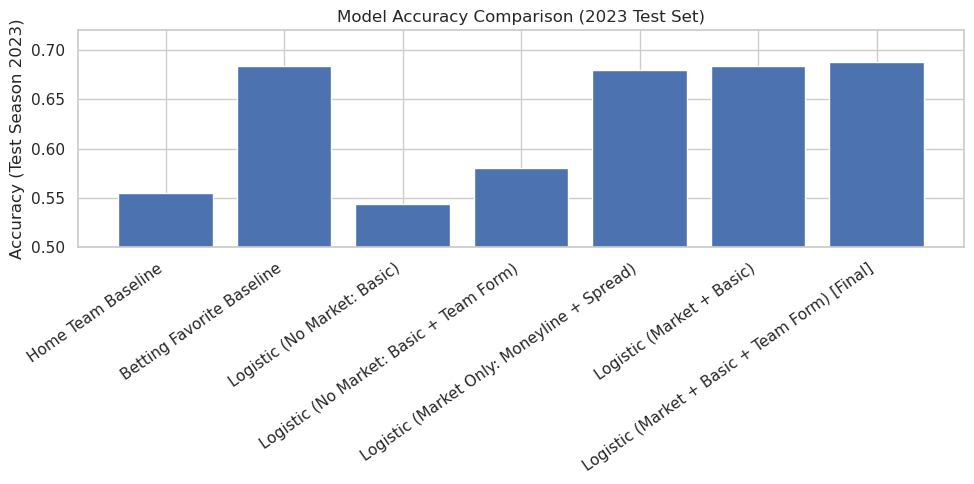

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Accuracy (Test Season 2023)")
plt.ylim(0.5, 0.72)
plt.title("Model Accuracy Comparison (2023 Test Set)")
plt.tight_layout()
plt.show()

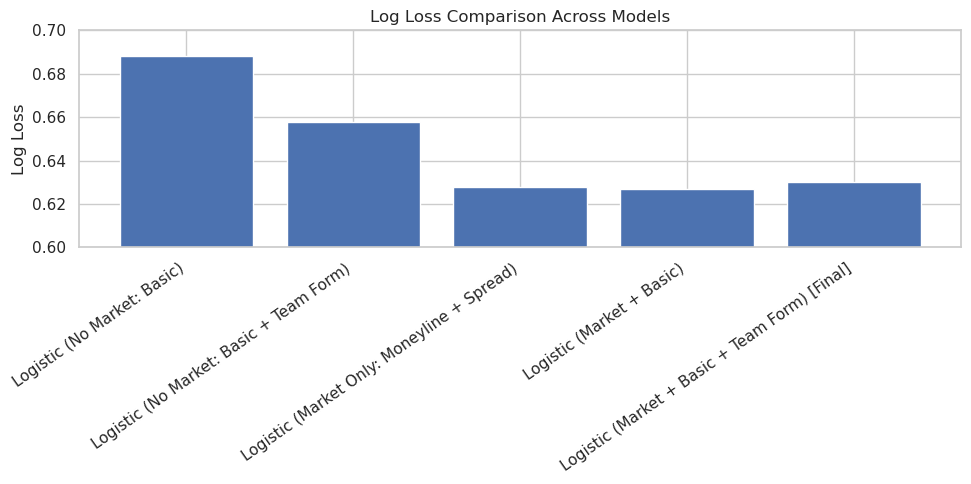

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(model_results["Model"], model_results["Log Loss"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Log Loss")
plt.ylim(0.60, 0.70)
plt.title("Log Loss Comparison Across Models")
plt.tight_layout()
plt.show()

### ROC Curve for Final Model

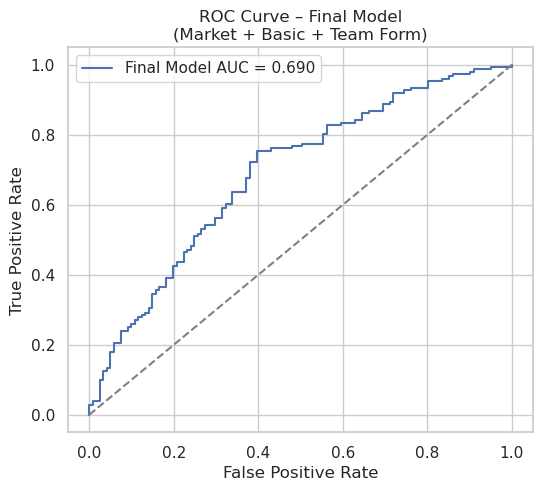

In [31]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, final_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Final Model AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Final Model\n(Market + Basic + Team Form)")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Results

From the accuracy comparison, the **betting favorite baseline** already performs
very well at about **68.4% accuracy**. The **final combined model** slightly improves
on this with about **68.8% accuracy**, which is a small but measurable gain.

The ROC curve for the final model shows a strong **AUC of about 0.69**, meaning the
model does a good job ranking games by how likely the home team is to win. Even
though the improvement in raw accuracy over Vegas is small, the large AUC indicates
that adding the team form features greatly improves the **quality and confidence** of
the probability estimates.

## Related Work

Previous studies on NFL game predictions have shown that betting market lines are
some of the strongest predictors of game outcomes. Many models that use only
team statistics struggle to beat the betting favorite in raw accuracy. Some work
has shown that adding recent performance trends and efficiency metrics can
improve probability estimates, even if accuracy gains are small. My results are
consistent with this pattern, since the final combined model mainly improves
ROC AUC rather than producing a large accuracy jump over Vegas.

## Conclusion

In this project, I looked at how well different models can predict whether the
home team wins an NFL game using data from the 2018–2023 regular seasons. I
compared simple baselines, non-market feature models, market-based models, and
came up with a final combined model.

The two baselines already showed how hard this problem was. Always picking the
home team reached about **55.5% accuracy**, while always picking the
betting favorite jumped to about **68.4% accuracy**. This showed early on that
Vegas lines are already very strong predictors.

For the non-market models, the basic version that only used rest, division, and
weather features performed poorly and even did worse than the home-team baseline.
After adding **team-form features** like recent win percentage and point
differential, the non-market model improved to about **58.1% accuracy** and a
much better AUC. This showed that recent team performance does contain a real
signal, but still cannot compete with the betting market.

The market-only logistic regression using moneyline and spread matched the
betting favorite baseline almost exactly. Adding the basic contextual features
to the market model did not meaningfully change the results, which suggests
that this type of information is already priced into the betting lines.

The final combined model, which used **market values + basic + team-form
features**, achieved the best overall performance with about **68.75% accuracy**
and a strong **ROC AUC of about 0.69**. While the raw accuracy improvement over
the betting favorite is small, the high AUC shows that the model is better at
ranking games by how likely the home team is to win. This suggests that team-form
features mainly help improve probability quality rather than simply boosting
win-loss accuracy.

My main takeaway from this project is that **betting markets are extremely
efficient**, and it is very difficult to beat them using only public data that is 
available before games start. However, by carefully engineering team performance 
features and combining them with market information, I believe it is still possible to 
slightly improve predictions.

In the future, I would like to extend upon this work by adding player level
statistics (especially quarterback data and injuries), tracking line movement
over time, and experimenting with more flexible models such as gradient
boosting to see if further improvements could be made.
